# Diffusion & Flow Exercise

This exercise demonstrates diffusion + convection and simple hemodynamics (Normal, Valsalva, Fibrosis, Combined). Run cells in order. Plots will be shown inline when possible.


## Quick diffusion timescales
Compute timescale for diffusion across different tissuethicknesses, with lengths of 1 µm and 1 mm.
Use the following equation:
$$t = \frac{x^2}{2D}$$
with $D = 1.8\cdot 10^{-3} mm^2/s$ for $O_2$-diffusion coefficient.

- What is the timescales for the two different tissue thicknesses 1 µm and 1 mm?
- Assume a timescale greater than 2 ms is too large for effecient diffusion of $O_2$, if only considering diffusion, what thickness is diffusion no longer viable?


In [ ]:
# %load files/diffusion_time.py
import math

D = 1.8e-3  # m^2/s, sammme som 1.8e-5 cm^2s^-1
x1 = 1e-3
x2 = 1

# Solution

## Fick + Convection (analytic steady 1D solution)


If we know the boundary conditions, the equation for Concentration (C) can be calculated using the following equation:
$$ C(x) = C_0 + (C_L - C_0)\frac{e^{v x / D} - 1}{e^{v L / D} - 1} $$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
C0 = 1.0  # mol/mm^3
CL = 0.1  # mol/mm^3
L = 0.2  # mm
v = 0.1  # mm/s
D = 1.8e-3  # mm^2/s

# Create position array from 0 to L
L = np.linspace(0.01 * L, L, 100)

# Compute concentration profile using analytical solution
C = C0 + (CL - C0) * np.expm1(v * L / D) / np.expm1(v * L / D)

# Plot the concentration profile
plt.figure(figsize=(8, 5))
plt.plot(L * 1e3, C, label="C(x)")
plt.xlabel("Tissue thickness (μm)")
plt.ylabel("Concentration [mol/mm³]")
plt.title("Oxygen Concentration Profile Across Tissue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



However, if we do not know the boundary conditions, or if the flow is diffusion dominated, we may use the differential equation $-D \frac{d^2C}{dx^2} + v \frac{dC}{dx} = 0$, which integrates into an exponential decay model, where $\lambda_{eff} = \sqrt{2 D \Delta t}$ and $\Delta t = \frac{L_{axial}}{v}$. 

$$ C(x) = C_0 * e^{\frac{-x}{\lambda_{eff}}} $$



### Flux 
We can use the steady 1D convection–diffusion equation to calculate flux:
    
$$ 
J_s = -D \frac{\partial C(x,t)}{\partial x} + J_v C(x,t) 
$$



### Peclet's Number
The Péclet number (Pe) is a dimensionless quantity representing the ratio of transport by convection (advection) to transport by diffusion, and for oxygen transfer from blood to a cell, it can be generally expressed as 
$$Pe = \frac{\text{convective transport​}}{\text{diffusive transport}}= \frac{v * L}{D}$$

Here:
* `v` is the characteristic fluid velocity (e.g., red blood cell velocity or plasma flow velocity)
* `L` is a characteristic length scale (such as the capillary radius or cell size)
* `D` is the diffusion coefficient of oxygen in the surrounding medium (e.g., plasma or tissue)

A high `Pe` value, where convection dominates, means oxygen is quickly transported by the flow, while a low value indicates diffusion is the primary transport mechanism


### Interpretation for Oxygen Transfer
- **Pe > 1 (Convection-Dominated):**
    When the Peclet number is significantly greater than 1, it signifies that the rate at which oxygen is transported by the fluid's bulk flow (convection) is much faster than its transport due to concentration gradients (diffusion). In this regime, the movement of oxygen is primarily dictated by the fluid's movement. 
- **Pe < 1 (Diffusion-Dominated):** 
    If the Peclet number is less than 1, diffusion becomes the dominant process for oxygen transport. The movement of oxygen is driven by its tendency to spread from areas of high concentration to areas of low concentration. 
- **Pe ≈ 1 (Mixed Regimes):**
    In situations where the Peclet number is around 1, both convection and diffusion are important and contribute to the overall transport of oxygen. 


### Example Application

- Microchannel studies: have shown that for small channel heights and high flow rates, the Péclet number is large, indicating that advection (convection) is the primary mode of oxygen transport. 
- In the microvascular system, the flow of blood and red blood cells moves oxygen towards the tissues. The Péclet number helps determine if the rate of delivery by this flow is sufficient to meet the metabolic demand of the tissue, or if diffusion-limited transport becomes the bottleneck. 


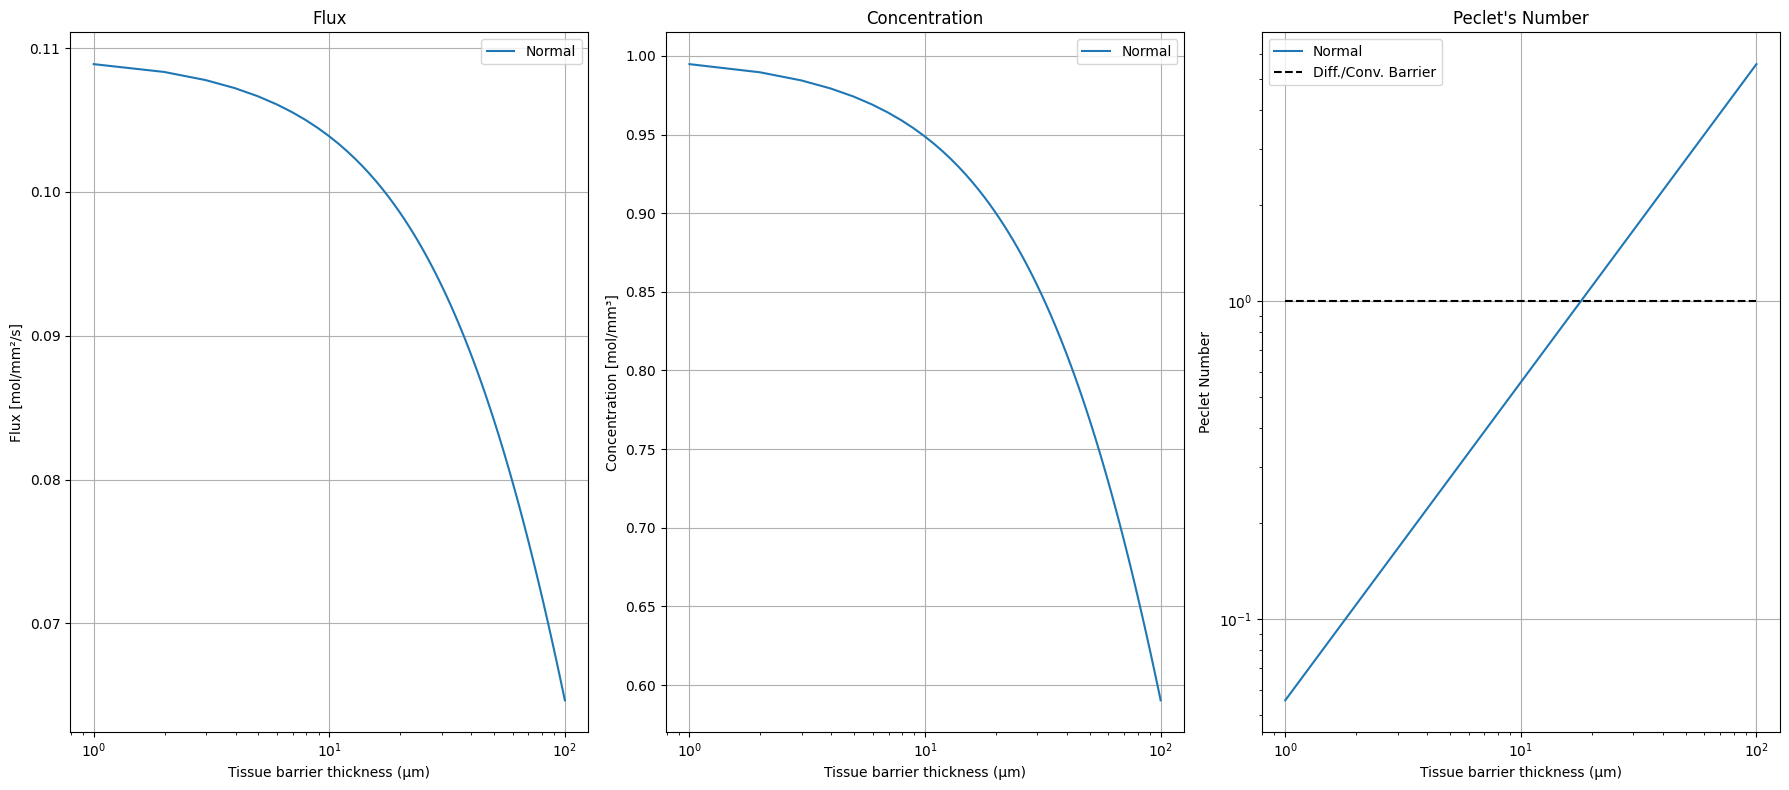

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes

L_axial = 1  # mm
L = 0.1  # mm
C0 = 1.0  # mol/mm^3
x = np.linspace(0.01 * L, L, 101)  # mm

conditions = {
    "Normal": {
        "v": 0.1,
        "D": 1.8e-3,
    },  # Normal Scenario, add new lines with different scenarios
}


def concentration(x, L_axial, v, D, C0):
    transit_time = L_axial / v
    lambda_eff = np.sqrt(2 * D * transit_time)
    C = C0 * np.exp(-x / lambda_eff)
    return C


def flux(x: np.ndarray, C: np.ndarray, v: float, D: float):
    dCdx = np.gradient(C, x)
    Jd = -D * dCdx
    Jc = v * C
    Js = Jd + Jc

    return Js


def peclet(L, D, v):
    Pe = L * v / D
    return Pe


# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 8))
axs: list[matplotlib.axes.Axes]

for i, (label, params) in enumerate(conditions.items()):
    v = params["v"]
    D = params["D"]

    # Flux components
    C = concentration(x, L_axial, v, D, C0)
    Js = flux(x, C, v, D)
    Pe = peclet(x, D, v)

    # Plot fluxes
    axs[0].plot(x * 1e3, Js, label=label)

    # Plot concentration
    axs[1].plot(x * 1e3, C, label=label)

    # Plot peclet
    axs[2].plot(x * 1e3, Pe, label=label)

axs[0].set_title("Flux")
axs[0].set_xlabel("Tissue barrier thickness (μm)")
axs[0].set_ylabel("Flux [mol/mm²/s]")
axs[0].set_xscale("log")
axs[0].grid(True)
axs[0].legend()
axs[1].set_title("Concentration")
axs[1].set_xlabel("Tissue barrier thickness (μm)")
axs[1].set_ylabel("Concentration [mol/mm³]")
axs[1].set_xscale("log")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(
    x * 1e3,
    np.ones_like(x),
    label="Diff./Conv. Barrier",
    linestyle="--",
    color="k",
)
axs[2].set_title("Peclet's Number")
axs[2].set_xlabel("Tissue barrier thickness (μm)")
axs[2].set_ylabel("Peclet Number")
axs[2].set_xscale("log")
axs[2].set_yscale("log")
axs[2].grid(True)
axs[2].legend()
plt.tight_layout()
plt.show()


## Physiological Scenarios in the Convection-Diffusion Model

The model is used to simulate solute transport across tissue barriers includes two key parameters:

- **v**: velocity of fluid flow (e.g., interstitial or capillary flow)
- **D**: diffusion coefficient of the solute (e.g., oxygen)

These parameters determine how solute concentration changes across the tissue. We are now going to simulate two scenarios.
1. Valsalva Maneuver
2. Fibrosis


## Extend the model to include three new conditions:
|| v | D |
|---|---|---|
|Valsalva| 0.3 | 1.8e-3 |
|Fibrosis| 0.1 | 0.9e-3 |
|Valsalva + Fibrosis| 0.3 | 0.9e-3 |


### Question

- **What happens to the solute transport in each case?**  
- **What effect does this have on oxygen delivery to deeper tissue?**



### Valsalva Maneuver

**Valsalva** is a forced exhalation against a closed airway, often used in clinical tests. It increases **intrathoracic pressure**, which can affect blood and interstitial flow.
In this task, you will simulate the **Valsalva Maneuver**, a physiological condition that increases intrathoracic pressure and fluid velocity.
- **Effect on $v$**: ↑ Increased velocity due to pressure-driven flow
- **Effect on $D$**: No direct change, but tissue compression may slightly alter diffusion



### Fibrosis
**Fibrosis** is the thickening and scarring of connective tissue, often due to chronic inflammation or disease.
- **Effect on  D**: ↓ Reduced diffusion due to dense extracellular matrix
- **Effect on  v**: May be unchanged or slightly reduced due to restricted flow


### Valsalva + Fibrosis
-  $v$ : ↑ Increased
-  $D$ : ↓ Decreased
